In [16]:
import pandas as pd

import numpy as np

import matplotlib.pyplot as plt

import seaborn as sns

In [17]:
atend = pd.read_csv("atendimentos.csv")

hosp = pd.read_csv("hospitais.csv")

In [18]:
atend.head()

,id_atendimento,data,hospital_id,especialidade,medico,idade,sexo,tempo_espera,tempo_atendimento,satisfacao,convenio,valor_consulta
0,1,2025-06-13,3,Cardiologia,Dra. Fernanda,15.0,M,11,45,2,SulAmérica,150.0
1,2,2025-06-01,4,Clínica Geral,Dr. Ricardo,55.0,M,13,13,1,Particular,150.0
2,3,2025-06-16,10,Pediatria,Dr. João,90.0,F,144,63,2,Unimed,220.0
3,4,2025-03-29,2,Neurologia,Dr. João,36.0,F,44,37,3,Amil,120.0
4,5,2025-06-04,7,Cardiologia,Dr. Ricardo,34.0,F,16,68,5,Amil,120.0


In [19]:
hosp.head()

,hospital_id,hospital,cidade,estado,regiao,quantidade_leitos,capacidade_dia,diretor,data_inauguracao
0,1,Hospital Central,brasília,DF,Centro-Oeste,250.0,400,Carlos Mendes,2010-03-15
1,2,Hospital Vida,Goiânia,GO,Centro-Oeste,180.0,320,Fernanda Lima,2012-08-20
2,3,Hospital Esperança,Anápolis,go,Centro-Oeste,140.0,260,Ricardo Alves,2014-11-10
3,4,Hospital Santa Luz,Brasília,DF,Centro Oeste,220.0,380,Mariana Rocha,2011-04-18
4,5,Hospital São Lucas,Uberlândia,MG,Sudeste,NaN,500,Paulo Silva,2009-09-05


In [20]:
atend.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id_atendimento     101 non-null    int64  
 1   data               101 non-null    object 
 2   hospital_id        101 non-null    int64  
 3   especialidade      101 non-null    object 
 4   medico             101 non-null    object 
 5   idade              100 non-null    float64
 6   sexo               101 non-null    object 
 7   tempo_espera       101 non-null    int64  
 8   tempo_atendimento  101 non-null    int64  
 9   satisfacao         101 non-null    int64  
 10  convenio           100 non-null    object 
 11  valor_consulta     100 non-null    float64
dtypes: float64(2), int64(5), object(5)
memory usage: 9.6+ KB


In [21]:
hosp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11 entries, 0 to 10
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   hospital_id        11 non-null     int64  
 1   hospital           11 non-null     object 
 2   cidade             11 non-null     object 
 3   estado             11 non-null     object 
 4   regiao             11 non-null     object 
 5   quantidade_leitos  10 non-null     float64
 6   capacidade_dia     11 non-null     int64  
 7   diretor            11 non-null     object 
 8   data_inauguracao   11 non-null     object 
dtypes: float64(1), int64(2), object(6)
memory usage: 924.0+ bytes


In [22]:
atend.describe()

,id_atendimento,hospital_id,idade,tempo_espera,tempo_atendimento,satisfacao,valor_consulta
count,101.000000,101.000000,100.000000,101.000000,101.000000,101.000000,100.000000
mean,50.108911,6.049505,46.410000,90.524752,49.910891,2.831683,220.300000
std,29.132422,9.694716,27.549806,53.282191,22.621273,1.463348,241.996974
min,1.000000,1.000000,-5.000000,-30.000000,10.000000,0.000000,-250.000000
25%,25.000000,3.000000,26.750000,45.000000,33.000000,2.000000,150.000000
50%,50.000000,4.000000,46.000000,91.000000,50.000000,3.000000,180.000000
75%,75.000000,7.000000,65.250000,131.000000,68.000000,4.000000,250.000000
max,100.000000,99.000000,150.000000,180.000000,90.000000,6.000000,2500.000000


In [23]:
atend.isnull().sum()

,0
id_atendimento,0
data,0
hospital_id,0
especialidade,0
medico,0
idade,1
sexo,0
tempo_espera,0
tempo_atendimento,0
satisfacao,0


In [24]:
atend.duplicated().sum()

np.int64(1)

In [25]:
# Quantidade de registros
print("Quantidade de registros:", len(atend))

# Valores ausentes
atend.isnull().sum()

Quantidade de registros: 101


,0
id_atendimento,0
data,0
hospital_id,0
especialidade,0
medico,0
idade,1
sexo,0
tempo_espera,0
tempo_atendimento,0
satisfacao,0


In [26]:
print("Duplicados:", atend.duplicated().sum())
atend = atend.drop_duplicates()
print("Novo total:", len(atend))

Duplicados: 1
Novo total: 100


In [27]:
# Idade → mediana
atend["idade"] = atend["idade"].fillna(
    atend["idade"].median()
)

# Satisfação → média
atend["satisfacao"] = atend["satisfacao"].fillna(
    atend["satisfacao"].mean()
)

# Convênio → "Não informado"
atend["convenio"] = atend["convenio"].fillna(
    "Não informado"
)

In [28]:
atend["data"] = pd.to_datetime(
    atend["data"],
    errors="coerce"
)

atend.dtypes

,0
id_atendimento,int64
data,datetime64[ns]
hospital_id,int64
especialidade,object
medico,object
idade,float64
sexo,object
tempo_espera,int64
tempo_atendimento,int64
satisfacao,int64


In [29]:
atend[
    atend["tempo_espera"] < 0
]

,id_atendimento,data,hospital_id,especialidade,medico,idade,sexo,tempo_espera,tempo_atendimento,satisfacao,convenio,valor_consulta
35,36,2025-04-24,2,Ortopedia,Dr. Ricardo,71.0,F,-30,81,1,Particular,120.0


In [30]:
atend.loc[
    atend["tempo_espera"] < 0,
    "tempo_espera"
] = np.nan

In [31]:
atend["tempo_espera"] = atend[
    "tempo_espera"
].fillna(
    atend["tempo_espera"].median()
)

In [32]:
atend["especialidade"] = (
    atend["especialidade"]
    .str.upper()
    .str.strip()
)

In [33]:
atend["especialidade"] = atend[
    "especialidade"
].replace(
    {
        "CARDIO":"CARDIOLOGIA",
        "CARDIOLOGIA ":"CARDIOLOGIA",
        "ORTOP":"ORTOPEDIA"
    }
)

In [34]:
atend["tempo_total"] = (
    atend["tempo_espera"] +
    atend["tempo_atendimento"]
)

In [35]:
atend["classificacao"] = np.where(
    atend["tempo_total"] <= 30,
    "Rápido",
    np.where(
        atend["tempo_total"] <= 60,
        "Normal",
        "Lento"
    )
)

In [40]:
bins = [0,18,40,60,120]

labels = [
    "0-18",
    "19-40",
    "41-60",
    "60+"
]

atend["faixa_etaria"] = pd.cut(
    atend["idade"],
    bins=bins,
    labels=labels
)

In [41]:
atend["faixa_etaria"].value_counts()

,count
faixa_etaria,
60+,32
19-40,28
41-60,21
0-18,17


In [38]:
atend.info()

<class 'pandas.core.frame.DataFrame'>
Index: 100 entries, 0 to 99
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   id_atendimento     100 non-null    int64         
 1   data               99 non-null     datetime64[ns]
 2   hospital_id        100 non-null    int64         
 3   especialidade      100 non-null    object        
 4   medico             100 non-null    object        
 5   idade              100 non-null    float64       
 6   sexo               100 non-null    object        
 7   tempo_espera       100 non-null    float64       
 8   tempo_atendimento  100 non-null    int64         
 9   satisfacao         100 non-null    int64         
 10  convenio           100 non-null    object        
 11  valor_consulta     99 non-null     float64       
 12  tempo_total        100 non-null    float64       
 13  classificacao      100 non-null    object        
 14  faixa_etaria    

In [39]:
atend.isnull().sum()

,0
id_atendimento,0
data,1
hospital_id,0
especialidade,0
medico,0
idade,0
sexo,0
tempo_espera,0
tempo_atendimento,0
satisfacao,0


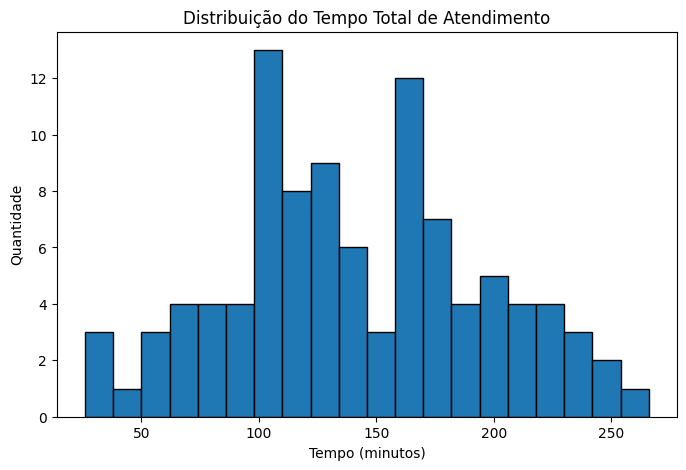

In [42]:
plt.figure(figsize=(8,5))

plt.hist(
    atend["tempo_total"],
    bins=20,
    edgecolor="black"
)

plt.title("Distribuição do Tempo Total de Atendimento")

plt.xlabel("Tempo (minutos)")

plt.ylabel("Quantidade")

plt.show()

In [43]:
#TRATANDO A BASE HOSPITAIS

In [44]:
hosp.head()

,hospital_id,hospital,cidade,estado,regiao,quantidade_leitos,capacidade_dia,diretor,data_inauguracao
0,1,Hospital Central,brasília,DF,Centro-Oeste,250.0,400,Carlos Mendes,2010-03-15
1,2,Hospital Vida,Goiânia,GO,Centro-Oeste,180.0,320,Fernanda Lima,2012-08-20
2,3,Hospital Esperança,Anápolis,go,Centro-Oeste,140.0,260,Ricardo Alves,2014-11-10
3,4,Hospital Santa Luz,Brasília,DF,Centro Oeste,220.0,380,Mariana Rocha,2011-04-18
4,5,Hospital São Lucas,Uberlândia,MG,Sudeste,NaN,500,Paulo Silva,2009-09-05


In [45]:
hosp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11 entries, 0 to 10
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   hospital_id        11 non-null     int64  
 1   hospital           11 non-null     object 
 2   cidade             11 non-null     object 
 3   estado             11 non-null     object 
 4   regiao             11 non-null     object 
 5   quantidade_leitos  10 non-null     float64
 6   capacidade_dia     11 non-null     int64  
 7   diretor            11 non-null     object 
 8   data_inauguracao   11 non-null     object 
dtypes: float64(1), int64(2), object(6)
memory usage: 924.0+ bytes


In [46]:
hosp.describe(include="all")

,hospital_id,hospital,cidade,estado,regiao,quantidade_leitos,capacidade_dia,diretor,data_inauguracao
count,11.000000,11,11,11,11,10.000000,11.000000,11,11
unique,NaN,10,10,4,3,NaN,NaN,10,10
top,NaN,Hospital Esperança,Anápolis,GO,Centro-Oeste,NaN,NaN,Ricardo Alves,2014-11-10
freq,NaN,2,2,5,9,NaN,NaN,2,2
mean,5.272727,NaN,NaN,NaN,NaN,184.000000,294.545455,NaN,NaN
std,2.969542,NaN,NaN,NaN,NaN,52.535702,157.566725,NaN,NaN
min,1.000000,NaN,NaN,NaN,NaN,120.000000,-100.000000,NaN,NaN
25%,3.000000,NaN,NaN,NaN,NaN,142.500000,250.000000,NaN,NaN
50%,5.000000,NaN,NaN,NaN,NaN,170.000000,320.000000,NaN,NaN
75%,7.500000,NaN,NaN,NaN,NaN,215.000000,390.000000,NaN,NaN


In [48]:
# Valores ausentes
hosp.isnull().sum()

,0
hospital_id,0
hospital,0
cidade,0
estado,0
regiao,0
quantidade_leitos,1
capacidade_dia,0
diretor,0
data_inauguracao,0


In [49]:
# Registros duplicados
hosp.duplicated().sum()

np.int64(1)

In [50]:
hosp = hosp.drop_duplicates()

In [51]:
print(hosp.shape)

(10, 9)


In [52]:
hosp["regiao"] = (
    hosp["regiao"]
        .str.upper()
        .str.strip()
)

hosp["cidade"] = (
    hosp["cidade"]
        .str.title()
        .str.strip()
)

hosp["estado"] = (
    hosp["estado"]
        .str.upper()
)

In [53]:
hosp["regiao"] = hosp["regiao"].replace({
    "CENTRO OESTE":"CENTRO-OESTE",
    "CENTROOESTE":"CENTRO-OESTE",
    "SUDESTE ":"SUDESTE"
})

In [54]:
hosp["capacidade_dia"] = (
    hosp["capacidade_dia"]
    .fillna(
        hosp["capacidade_dia"].median()
    )
)

hosp["quantidade_leitos"] = (
    hosp["quantidade_leitos"]
    .fillna(
        hosp["quantidade_leitos"].median()
    )
)

In [56]:
hosp["data_inauguracao"] = pd.to_datetime(
    hosp["data_inauguracao"],
    errors="coerce"
)

In [57]:
hosp.dtypes

,0
hospital_id,int64
hospital,object
cidade,object
estado,object
regiao,object
quantidade_leitos,float64
capacidade_dia,int64
diretor,object
data_inauguracao,datetime64[ns]


In [59]:
ano_atual = 2025

hosp["anos_operacao"] = (
    ano_atual -
    hosp["data_inauguracao"].dt.year
)

In [60]:
hosp["porte"] = pd.cut(
    hosp["quantidade_leitos"],
    bins=[0,100,250,1000],
    labels=[
        "Pequeno",
        "Médio",
        "Grande"
    ]
)

In [61]:
hosp["hospital_id"].nunique()

10

In [62]:
atend["hospital_id"].nunique()

11

In [63]:
set(atend["hospital_id"]) - set(hosp["hospital_id"])

{99}

In [64]:
atend[~atend["hospital_id"].isin(hosp["hospital_id"])]

,id_atendimento,data,hospital_id,especialidade,medico,idade,sexo,tempo_espera,tempo_atendimento,satisfacao,convenio,valor_consulta,tempo_total,classificacao,faixa_etaria
65,66,2025-01-18,99,CARDIOLOGIA,Dra. Carla,65.0,F,170.0,53,1,Amil,220.0,223.0,Lento,60+


In [65]:
atend.loc[atend["hospital_id"] == 99, "hospital_id"] = 9

In [66]:
set(atend["hospital_id"]) - set(hosp["hospital_id"])

set()

In [67]:
atend.to_csv(
    "atendimentos_tratado.csv",
    index=False,
    encoding="utf-8-sig"
)

hosp.to_csv(
    "hospitais_tratado.csv",
    index=False,
    encoding="utf-8-sig"
)